In [9]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import seaborn as sns

# For the custom legend
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

from my_fun import save_notebook_files
from plotting_style import *

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [3]:
# Plotting style
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'svg'
# %config InlineBackend.figure_format = 'retina'

In [4]:
# Load stimuli set
path = r'C:\Users\Usuario\PycharmProjects\create_sounds\sounds_6.1.csv'
path = Path.home() / 'PycharmProjects' / 'create_sounds' / 'sounds_6.1.csv'
df = pd.read_csv(path)

In [5]:
# Compute the mean of left envelopes (EL) per row
df['EL_mean'] = df.loc[:, 'EL0':'EL10'].mean(axis=1)  # Add 'EL_mean' to the DataFrame
EL_mean_min = round(min(df.EL_mean[0:-1]), -1)  # Exclude the last value for EL_mean_min (0)
EL_mean_max = round(max(df.EL_mean))

# Compute the mean of right envelopes (ER) per row
df['ER_mean'] = df.loc[:, 'ER0':'ER10'].mean(axis=1)  # Add 'ER_mean' to the DataFram
ER_mean_min = round(min(df.ER_mean[1:]), -1)  # Exclude the first value for EL_mean_min (0)
ER_mean_max = round(max(df.ER_mean))

# Compute ILD as the difference between EL_mean and ER_mean for coloring
df['abs_ILD'] = df.ILD.abs()  # Take absolute ILD values for color grouping
unique_abs_ilds = sorted(df.abs_ILD.unique())  # Get unique absolute ILD values and assign colors
unique_ilds = sorted(df.ILD.unique())  # Get unique ILD values for labeling

cmap_colors = get_cmap('tab20c').colors
colors = {
    -70: cmap_colors[0],  # Dark blue
    -8: cmap_colors[1],  # Medium dark blue
    -4: cmap_colors[2],  # Medium light blue
    -2: cmap_colors[3],  # Light blue
    0:  cmap_colors[19],  # Light gray
    2: cmap_colors[7],  # Dark blue
    4: cmap_colors[6],  # Medium dark blue
    8: cmap_colors[5],  # Medium light blue
    70: cmap_colors[4]  # Light blue
}

# Create a dictionary to map absolute ILD values to colors
# abs_ild_to_color = {abs_ild: cmap(i) for i, abs_ild in enumerate(unique_abs_ilds)}

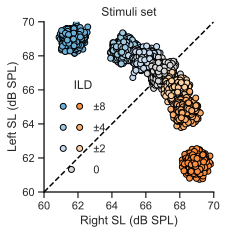

In [7]:
# Plot each group (based on absolute ILD)
figsize=fig_size(n_cols=2)
figsize=(figsize[0], figsize[0])  # Make it square
plt.figure(figsize=figsize, constrained_layout=True)
plt.axis('square')

# Plot equity line
plt.plot(np.arange(ER_mean_min, ER_mean_max + 1), np.arange(ER_mean_min, ER_mean_max + 1), color='k', linestyle='--', zorder=0)

# for abs_ild in unique_abs_ilds:
for ild in unique_ilds:
        subset = df[df.ILD == ild]
        plt.scatter(subset.ER_mean, subset.EL_mean, color=colors[ild], edgecolor='k')

plt.xlim(EL_mean_min, EL_mean_max)
plt.ylim(ER_mean_min, ER_mean_max)
# plt.xlim(0, EL_mean_max)  # To show max right ILDs (+70)
# plt.ylim(0, ER_mean_max)  # # To show max left ILDs (-70)
plt.title(f'Stimuli set')
plt.xlabel('Right SL (dB SPL)')
plt.ylabel('Left SL (dB SPL)')
# plt.legend(loc='lower left', title='ILD', frameon=False)
plt.grid(False)
# plt.tight_layout()
sns.despine()


# Custom legend

# Create legend handles as tuples (negative dot, positive dot)
legend_handles = [
    # (
    #     Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[-70], markeredgecolor='k'),
    #     Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[70], markeredgecolor='k')
    # ),
    (
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[-8], markeredgecolor='k'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[8], markeredgecolor='k')
    ),
    (
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[-4], markeredgecolor='k'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[4], markeredgecolor='k')
    ),
    (
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[-2], markeredgecolor='k'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[2], markeredgecolor='k')
    ),
]

# Add single handle for 0 (gray dot)
zero_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[0], markeredgecolor='k')

# Add zero handle at the end of handles list
legend_handles.append(zero_handle)

# Labels
labels = [
    # '±70',
    '±8', '±4', '±2', '0']

plt.legend(
    handles=legend_handles,
    labels=labels,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    title='ILD',
    ncol=1,
    handletextpad=1,
    borderpad=1,
    labelspacing=1,
    frameon=False,
)

# Save all notebook's outputs

In [10]:
# # Whole notebook outputs (no input or prompt, only Markdown and figures)
# # As HTML
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# # As PDF
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt
#
# Export all figures
save_notebook_files(notebook_path='notebook.ipynb')

Saved 1 images to notebook_files/
